# Feature engineering

In [134]:
# Importar librerias
import pandas as pd
import numpy as np

# Cargar archivos
trans_df = pd.read_csv("../data/hey_transacciones.csv")
clientes_df = pd.read_csv("../data/hey_clientes.csv")


In [135]:
# Tipo de transacciones donde entra dinero
ingresos_ops = [
    "transf_entrada",
    "deposito_oxxo",
    "deposito_farmacia",
    "devolucion",
    "abono_inversion",
    "cashback"
]

# Tipo de transacciones donde sale dinero
egresos_ops = [
    "compra",
    "transf_salida",
    "retiro_cajero",
    "pago_servicio",
    "pago_credito",
    "abono_inversion",
    "cargo_recurrente"
]

# Variables para quitar
cols_to_drop = [
    "comercio_nombre",
    "ciudad_transaccion",
    "intento_numero",
    "dia_semana",
    "descripcion_libre",
    "canal",
    "dispositivo",
    "motivo_no_procesada",
    "fecha_hora",
    "hora_del_dia",
    "es_internacional",
    "patron_uso_atipico",
    "cashback_generado",
    "meses_diferidos",
    "dispositivo",
    "es_dato_sintetico"
]


In [136]:
trans_df = trans_df.drop(columns=cols_to_drop)

In [137]:
trans_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 802384 entries, 0 to 802383
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaccion_id  802384 non-null  str    
 1   user_id         802384 non-null  str    
 2   producto_id     802384 non-null  str    
 3   tipo_operacion  802384 non-null  str    
 4   monto           802384 non-null  float64
 5   categoria_mcc   802384 non-null  str    
 6   estatus         802384 non-null  str    
dtypes: float64(1), str(6)
memory usage: 42.9 MB


In [138]:
num_txn = (
    trans_df
    .groupby("user_id")
    .size()
    .rename("num_transacciones")
)

In [139]:
trans_df["flujo"] = np.where(
    trans_df["tipo_operacion"].isin(ingresos_ops),
    "ingreso",
    "egreso"
)
trans_df = trans_df.drop(columns="tipo_operacion")

In [140]:
trans_df.head()

,transaccion_id,user_id,producto_id,monto,categoria_mcc,estatus,flujo
0,TXN-0000000055,USR-00001,PRD-00000002,33.88,entretenimiento,completada,egreso
1,TXN-0000000048,USR-00001,PRD-00000001,249.00,servicios_digitales,completada,egreso
2,TXN-0000000018,USR-00001,PRD-00000001,399.00,servicios_digitales,completada,egreso
3,TXN-0000000043,USR-00001,PRD-00000001,8910.00,transferencia,completada,egreso
4,TXN-0000000009,USR-00001,PRD-00000001,568.59,restaurante,completada,egreso


In [141]:
flujo_por_usuario = (
    trans_df
    .groupby(["user_id", "flujo"])["monto"]
    .sum()
    .unstack(fill_value=0)
)

In [142]:
clientes_df = clientes_df.merge(
    flujo_por_usuario,
    on="user_id",
    how="left"
)

In [143]:
clientes_df.head()

trans_df = trans_df.drop(columns="flujo")
trans_df.head()

,transaccion_id,user_id,producto_id,monto,categoria_mcc,estatus
0,TXN-0000000055,USR-00001,PRD-00000002,33.88,entretenimiento,completada
1,TXN-0000000048,USR-00001,PRD-00000001,249.00,servicios_digitales,completada
2,TXN-0000000018,USR-00001,PRD-00000001,399.00,servicios_digitales,completada
3,TXN-0000000043,USR-00001,PRD-00000001,8910.00,transferencia,completada
4,TXN-0000000009,USR-00001,PRD-00000001,568.59,restaurante,completada


Transacciones no procesadas

In [144]:
df_no_proc = trans_df[trans_df["estatus"] == "no_procesada"]

In [145]:
no_proc_por_usuario = (
    df_no_proc
    .groupby("user_id")
    .size()
    .rename("num_no_procesadas")
)

In [146]:
clientes_df = clientes_df.merge(
    no_proc_por_usuario,
    on="user_id",
    how="left"
)

In [147]:
clientes_df["num_no_procesadas"] = clientes_df["num_no_procesadas"].fillna(0)

In [148]:
clientes_df.head()

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico,egreso,ingreso,num_no_procesadas
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,10.0,False,True,es_MX,False,2,False,96533.95,23036.64,3.0
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,8.0,False,True,es_MX,True,2,False,110639.95,102082.72,1.0
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,8.0,False,True,es_MX,False,2,False,108134.22,82666.87,4.0
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,...,10.0,True,False,es_MX,True,3,False,336623.74,243490.00,2.0
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,...,7.0,False,True,es_MX,True,2,False,121244.77,69032.53,2.0


In [149]:
clientes_df["num_no_procesadas"].nunique()

14

In [150]:
clientes_df["num_no_procesadas"].unique()

array([ 3.,  1.,  4.,  2.,  5.,  0.,  6.,  9.,  7., 10.,  8., 12., 11.,
       14.])

In [151]:
clientes_df["num_no_procesadas"].value_counts().sort_index()

num_no_procesadas
0.0     3927
1.0     4051
2.0     3022
3.0     1894
4.0     1002
5.0      533
6.0      293
7.0      154
8.0       71
9.0       42
10.0      26
11.0       5
12.0       4
14.0       1
Name: count, dtype: int64

In [152]:
clientes_df["num_no_procesadas"].value_counts().sum()

np.int64(15025)

In [153]:
clientes_df["saldo"] = clientes_df["ingreso"] - clientes_df["egreso"]
clientes_df.drop(columns=["ingreso", "egreso"], inplace=True)

In [154]:
clientes_df = clientes_df.merge(
    num_txn,
    on="user_id",
    how="left"
)

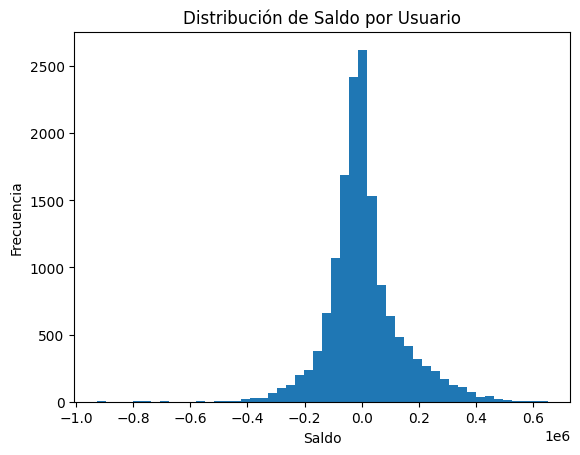

In [155]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(clientes_df["saldo"], bins=50)
plt.xlabel("Saldo")
plt.ylabel("Frecuencia")
plt.title("Distribución de Saldo por Usuario")
plt.show()

In [156]:
clientes_df.head()

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico,num_no_procesadas,saldo,num_transacciones
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,10.0,False,True,es_MX,False,2,False,3.0,-73497.31,56
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,8.0,False,True,es_MX,True,2,False,1.0,-8557.23,74
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,8.0,False,True,es_MX,False,2,False,4.0,-25467.35,79
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,...,10.0,True,False,es_MX,True,3,False,2.0,-93133.74,66
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,...,7.0,False,True,es_MX,True,2,False,2.0,-52212.24,93
